## ASE + YAML: An Introduction to Structure Optimization and Molecular Dynamics

### Write to YAML configuration file

In [5]:
yaml_text = """
system:
  name: Cu_bulk
  lattice_constant: 3.6
  supercell: [2, 2, 2]
  pbc: [true, true, true]

optimization:
  fmax: 0.02
  steps: 100
  trajectory: opt.traj

md:
  temperature_K: 300
  timestep_fs: 1.0
  steps: 200
  trajectory: md.traj
  log_interval: 10
"""

with open("config_advanced.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("config_advanced.yaml 已生成")

config_advanced.yaml 已生成


### Read YAML configuration

In [16]:
import yaml

with open("config_advanced.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg

{'system': {'name': 'Cu_bulk',
  'lattice_constant': 3.6,
  'supercell': [2, 2, 2],
  'pbc': [True, True, True]},
 'optimization': {'fmax': 0.02, 'steps': 100, 'trajectory': 'opt.traj'},
 'md': {'temperature_K': 300,
  'timestep_fs': 1.0,
  'steps': 200,
  'trajectory': 'md.traj',
  'log_interval': 10}}

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation
from ase import units
from ase.io import write, Trajectory

### Create a crystal structure

In [18]:
system_cfg = cfg["system"]

a = system_cfg["lattice_constant"]
supercell = tuple(system_cfg["supercell"])

atoms = bulk("Cu", "fcc", a=a, cubic=True) * supercell
atoms.set_pbc(system_cfg["pbc"])

print(atoms)
print("原子数 =", len(atoms))
print("晶胞 =")
print(atoms.cell)

Atoms(symbols='Cu32', pbc=True, cell=[7.2, 7.2, 7.2])
原子数 = 32
晶胞 =
Cell([7.2, 7.2, 7.2])


### View initial structure

In [19]:
from ase.visualize import view
view(atoms, viewer='x3d')

In [20]:
print("初始原子坐标：")
print(atoms.get_positions()[:5])  # 只显示前5个

初始原子坐标：
[[0.  0.  0. ]
 [0.  1.8 1.8]
 [1.8 0.  1.8]
 [1.8 1.8 0. ]
 [0.  0.  3.6]]


### Set up the calculator

In [21]:
atoms.calc = EMT()

energy_initial = atoms.get_potential_energy()
forces_initial = atoms.get_forces()

print(f"初始势能 = {energy_initial:.6f} eV")
print("初始受力（前5个原子）=")
print(forces_initial[:5])

初始势能 = -0.214041 eV
初始受力（前5个原子）=
[[-2.74433254e-15 -2.73739365e-15 -5.32560107e-15]
 [ 1.49533164e-15  1.89084859e-15  2.27248775e-15]
 [-1.23200061e-14  5.06192310e-15  2.73045475e-15]
 [-9.52016244e-15 -1.15098903e-14  1.50227053e-15]
 [-1.42108547e-14 -5.32907052e-15 -3.93435284e-15]]


### Perform a simple structural perturbation

In [22]:
np.random.seed(42)
atoms.rattle(stdev=0.05)

print("加入随机扰动后的坐标（前5个原子）:")
print(atoms.get_positions()[:5])

加入随机扰动后的坐标（前5个原子）:
[[ 0.02483571 -0.00691322  0.03238443]
 [ 0.07615149  1.78829233  1.78829315]
 [ 1.87896064  0.03837174  1.77652628]
 [ 1.827128    1.77682912 -0.02328649]
 [ 0.01209811 -0.09566401  3.51375411]]


### Structural optimization

In [23]:
opt_cfg = cfg["optimization"]

optimizer = BFGS(atoms, trajectory=opt_cfg["trajectory"], logfile="-")
optimizer.run(fmax=opt_cfg["fmax"], steps=opt_cfg["steps"])

      Step     Time          Energy          fmax
BFGS:    0 16:59:44        0.567024        1.328035
BFGS:    1 16:59:44        0.352622        1.039651
BFGS:    2 16:59:44       -0.108055        0.361532
BFGS:    3 16:59:44       -0.132087        0.334086
BFGS:    4 16:59:44       -0.166066        0.255816
BFGS:    5 16:59:44       -0.187426        0.168551
BFGS:    6 16:59:44       -0.197408        0.152108
BFGS:    7 16:59:45       -0.201654        0.126579
BFGS:    8 16:59:45       -0.206142        0.115747
BFGS:    9 16:59:45       -0.210248        0.094383
BFGS:   10 16:59:45       -0.212309        0.051818
BFGS:   11 16:59:45       -0.213029        0.044116
BFGS:   12 16:59:45       -0.213453        0.033256
BFGS:   13 16:59:45       -0.213805        0.018726


True

### Optimized results

In [25]:
energy_opt = atoms.get_potential_energy()
forces_opt = atoms.get_forces()

print(f"优化后势能 = {energy_opt:.6f} eV")
print("优化后最大力 = {:.6f} eV/Å".format(np.abs(forces_opt).max()))

优化后势能 = -0.213805 eV
优化后最大力 = 0.018323 eV/Å


In [26]:
write("opt_final.xyz", atoms)
print("优化后结构已保存到 opt_final.xyz")

优化后结构已保存到 opt_final.xyz


### 读取优化轨迹并画能量变化

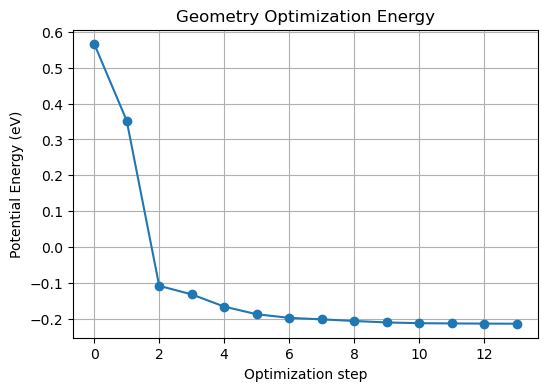

In [27]:
traj = Trajectory(opt_cfg["trajectory"])

energies = [img.get_potential_energy() for img in traj]

plt.figure(figsize=(6, 4))
plt.plot(range(len(energies)), energies, marker="o")
plt.xlabel("Optimization step")
plt.ylabel("Potential Energy (eV)")
plt.title("Geometry Optimization Energy")
plt.grid(True)
plt.show()

### 重新从优化后结构开始 MD

In [28]:
atoms_md = atoms.copy()
atoms_md.calc = EMT()

In [29]:
md_cfg = cfg["md"]

MaxwellBoltzmannDistribution(atoms_md, temperature_K=md_cfg["temperature_K"])
Stationary(atoms_md)     # 去掉整体平动
ZeroRotation(atoms_md)   # 去掉整体转动

In [30]:
epot = atoms_md.get_potential_energy()
ekin = atoms_md.get_kinetic_energy()
temp = ekin / (1.5 * len(atoms_md) * units.kB)

print(f"初始势能 = {epot:.6f} eV")
print(f"初始动能 = {ekin:.6f} eV")
print(f"初始温度 = {temp:.2f} K")

初始势能 = -0.213805 eV
初始动能 = 1.066650 eV
初始温度 = 257.87 K


In [31]:
dyn = VelocityVerlet(
    atoms_md,
    timestep=md_cfg["timestep_fs"] * units.fs,
    trajectory=md_cfg["trajectory"],
    logfile=None
)

In [32]:
steps_record = []
epot_record = []
ekin_record = []
temp_record = []
etot_record = []

def record_md():
    step = dyn.nsteps
    epot = atoms_md.get_potential_energy()
    ekin = atoms_md.get_kinetic_energy()
    temp = ekin / (1.5 * len(atoms_md) * units.kB)
    etot = epot + ekin

    steps_record.append(step)
    epot_record.append(epot)
    ekin_record.append(ekin)
    temp_record.append(temp)
    etot_record.append(etot)

    if step % md_cfg["log_interval"] == 0:
        print(f"Step {step:4d} | "
              f"Epot = {epot:10.4f} eV | "
              f"Ekin = {ekin:10.4f} eV | "
              f"Etot = {etot:10.4f} eV | "
              f"T = {temp:8.2f} K")

In [33]:
dyn.attach(record_md, interval=1)
record_md()  # 先记录 step=0
dyn.run(md_cfg["steps"])

Step    0 | Epot =    -0.2138 eV | Ekin =     1.0666 eV | Etot =     0.8528 eV | T =   257.87 K
Step    0 | Epot =    -0.2138 eV | Ekin =     1.0666 eV | Etot =     0.8528 eV | T =   257.87 K
Step   10 | Epot =    -0.0984 eV | Ekin =     0.9513 eV | Etot =     0.8529 eV | T =   229.99 K
Step   20 | Epot =     0.1962 eV | Ekin =     0.6568 eV | Etot =     0.8530 eV | T =   158.79 K
Step   30 | Epot =     0.5081 eV | Ekin =     0.3450 eV | Etot =     0.8531 eV | T =    83.40 K
Step   40 | Epot =     0.6708 eV | Ekin =     0.1823 eV | Etot =     0.8531 eV | T =    44.07 K
Step   50 | Epot =     0.6312 eV | Ekin =     0.2218 eV | Etot =     0.8531 eV | T =    53.63 K
Step   60 | Epot =     0.4753 eV | Ekin =     0.3777 eV | Etot =     0.8530 eV | T =    91.31 K
Step   70 | Epot =     0.3346 eV | Ekin =     0.5183 eV | Etot =     0.8529 eV | T =   125.31 K
Step   80 | Epot =     0.2835 eV | Ekin =     0.5695 eV | Etot =     0.8529 eV | T =   137.68 K
Step   90 | Epot =     0.3092 eV | Ekin 

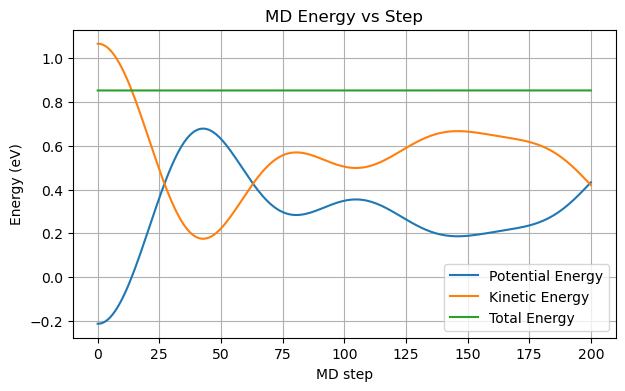

In [34]:
plt.figure(figsize=(7, 4))
plt.plot(steps_record, epot_record, label="Potential Energy")
plt.plot(steps_record, ekin_record, label="Kinetic Energy")
plt.plot(steps_record, etot_record, label="Total Energy")
plt.xlabel("MD step")
plt.ylabel("Energy (eV)")
plt.title("MD Energy vs Step")
plt.legend()
plt.grid(True)
plt.show()

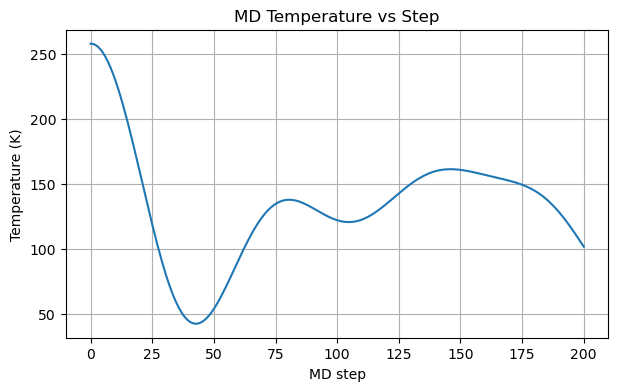

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(steps_record, temp_record)
plt.xlabel("MD step")
plt.ylabel("Temperature (K)")
plt.title("MD Temperature vs Step")
plt.grid(True)
plt.show()

In [36]:
write("md_final.xyz", atoms_md)
print("MD 最终结构已保存到 md_final.xyz")

MD 最终结构已保存到 md_final.xyz
